In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [2]:

# Load clustered dataset
df = pd.read_csv(r"C:\Users\Sam\Desktop\Spotify_Genre_Segmentation\data\output\spotify_clustered.csv")

In [3]:

# Features used for clustering
features = ["danceability", "energy", "loudness", "speechiness",
            "acousticness", "instrumentalness", "liveness",
            "valence", "tempo"]

In [4]:

X = df[features]

In [5]:

# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [6]:

# Apply PCA (reduce to 2 dimensions)
pca = PCA(n_components=2)
pca_result = pca.fit_transform(X_scaled)

In [7]:

# Add PCA values into dataframe
df["pca1"] = pca_result[:, 0]
df["pca2"] = pca_result[:, 1]

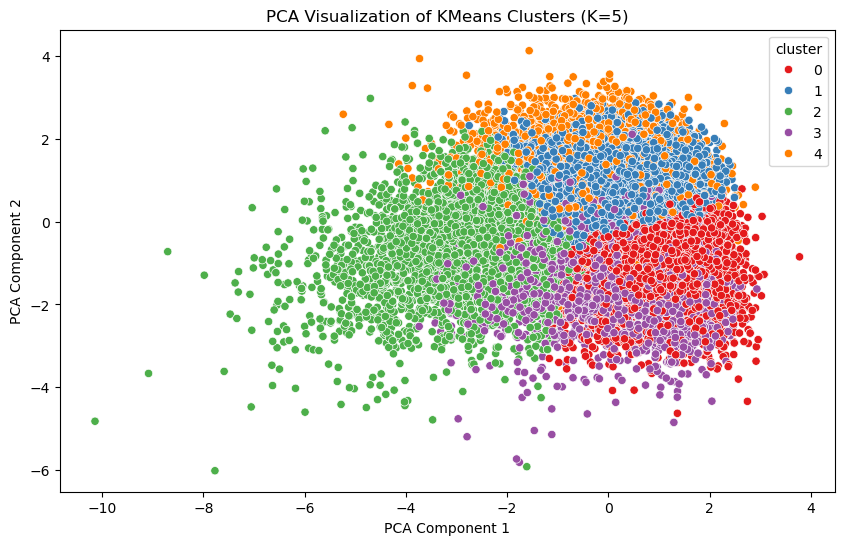

Explained Variance Ratio: [0.23912259 0.16756647]
Total Variance Explained: 0.4066890605340149


In [8]:

# Plot PCA clusters
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x="pca1", y="pca2", hue="cluster", palette="Set1")
plt.title("PCA Visualization of KMeans Clusters (K=5)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.show()

# Explained variance ratio
print("Explained Variance Ratio:", pca.explained_variance_ratio_)
print("Total Variance Explained:", sum(pca.explained_variance_ratio_))